In this training we will use the sentiments with the modified_financial_data.csv with xgbost model

In [48]:
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
import missingno as msno 
import matplotlib.pyplot as plt 
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np 

In [20]:
path = r"C:\Users\User\dev\training_model\dataset\modified_financial_data.csv"
df = pd.read_csv(path)
df.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date
0,2058.199951,114.080002,159.119995,15.11,1.208941,2015-01-02
1,2020.579956,115.800003,150.320007,15.50,1.194643,2015-01-05
2,2002.609985,117.120003,144.399994,15.83,1.193902,2015-01-06
3,2025.900024,116.430000,146.960007,15.85,1.187536,2015-01-07
4,2062.139893,115.940002,148.399994,15.64,1.183600,2015-01-08


In [21]:
path = r"C:\Users\User\dev\training_model\gdelt_gold_news_sentiments.csv"
news = pd.read_csv(path)
news.head()

,date,text,sentiment
0,2015-12-27,Here's a summary of gold-related news based on...,negative
1,2015-12-28,Several reports discuss gold smuggling attempt...,positive
2,2015-12-29,Several reports discuss gold smuggling attempt...,positive
3,2015-12-30,Here's a summary of gold market news from the ...,positive
4,2015-12-31,Here's a summary of gold market news from the ...,positive


In [22]:
df["Date"] = pd.to_datetime(df["Date"])
news["date"] = pd.to_datetime(news["date"])

merged = pd.merge(df, news, left_on="Date", right_on="date", how="inner")

In [23]:
merged.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,date,text,sentiment
0,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2015-12-28,Several reports discuss gold smuggling attempt...,positive
1,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2015-12-29,Several reports discuss gold smuggling attempt...,positive
2,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2015-12-30,Here's a summary of gold market news from the ...,positive
3,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2015-12-31,Here's a summary of gold market news from the ...,positive
4,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,2016-01-04,"Gold prices climbed above $1,080/oz amid Middl...",positive


In [24]:
merged = merged.sort_values(by="Date")

In [25]:
merged.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,date,text,sentiment
0,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2015-12-28,Several reports discuss gold smuggling attempt...,positive
1,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2015-12-29,Several reports discuss gold smuggling attempt...,positive
2,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2015-12-30,Here's a summary of gold market news from the ...,positive
3,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2015-12-31,Here's a summary of gold market news from the ...,positive
4,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,2016-01-04,"Gold prices climbed above $1,080/oz amid Middl...",positive


In [26]:
drop = ['date', 'text']
merged = merged.drop(columns=drop, errors='ignore')
merged.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,sentiment
0,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,positive
1,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,positive
2,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,positive
3,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,positive
4,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,positive


In [27]:
le = LabelEncoder()
merged['sentiment_encoded'] = le.fit_transform(merged['sentiment'])
merged.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,sentiment,sentiment_encoded
0,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,positive,2
1,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,positive,2
2,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,positive,2
3,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,positive,2
4,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,positive,2


In [29]:
merged = merged.drop(columns=['sentiment'], errors='ignore')
merged.head()

,^GSPC,GLD,USO,SLV,EURUSD=X,Date,sentiment_encoded
0,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2
1,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2
2,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2
3,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2
4,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,2


In [31]:
columns_to_lag = merged.columns

for col in columns_to_lag:
    merged[f'{col}_lag_1'] = merged[col].shift(1)

In [ ]:
drop = ['^GSPC	', 'USO', 'SLV', 'EURUSD=X', 'Date', 'sentiment_encoded']
merged = merged.drop(columns=drop, errors='ignore')

,^GSPC,GLD,^GSPC_lag_1,GLD_lag_1,USO_lag_1,SLV_lag_1,EURUSD=X_lag_1,Date_lag_1,sentiment_encoded_lag_1
0,2056.500000,102.269997,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,2078.360107,102.199997,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2.0
2,2063.360107,101.419998,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2.0
3,2043.939941,101.459999,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2.0
4,2012.660034,102.889999,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2.0


In [38]:
merged.head()

,GLD,^GSPC_lag_1,GLD_lag_1,USO_lag_1,SLV_lag_1,EURUSD=X_lag_1,Date_lag_1,sentiment_encoded_lag_1
0,102.269997,NaN,NaN,NaN,NaN,NaN,NaT,NaN
1,102.199997,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2.0
2,101.419998,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2.0
3,101.459999,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2.0
4,102.889999,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2.0


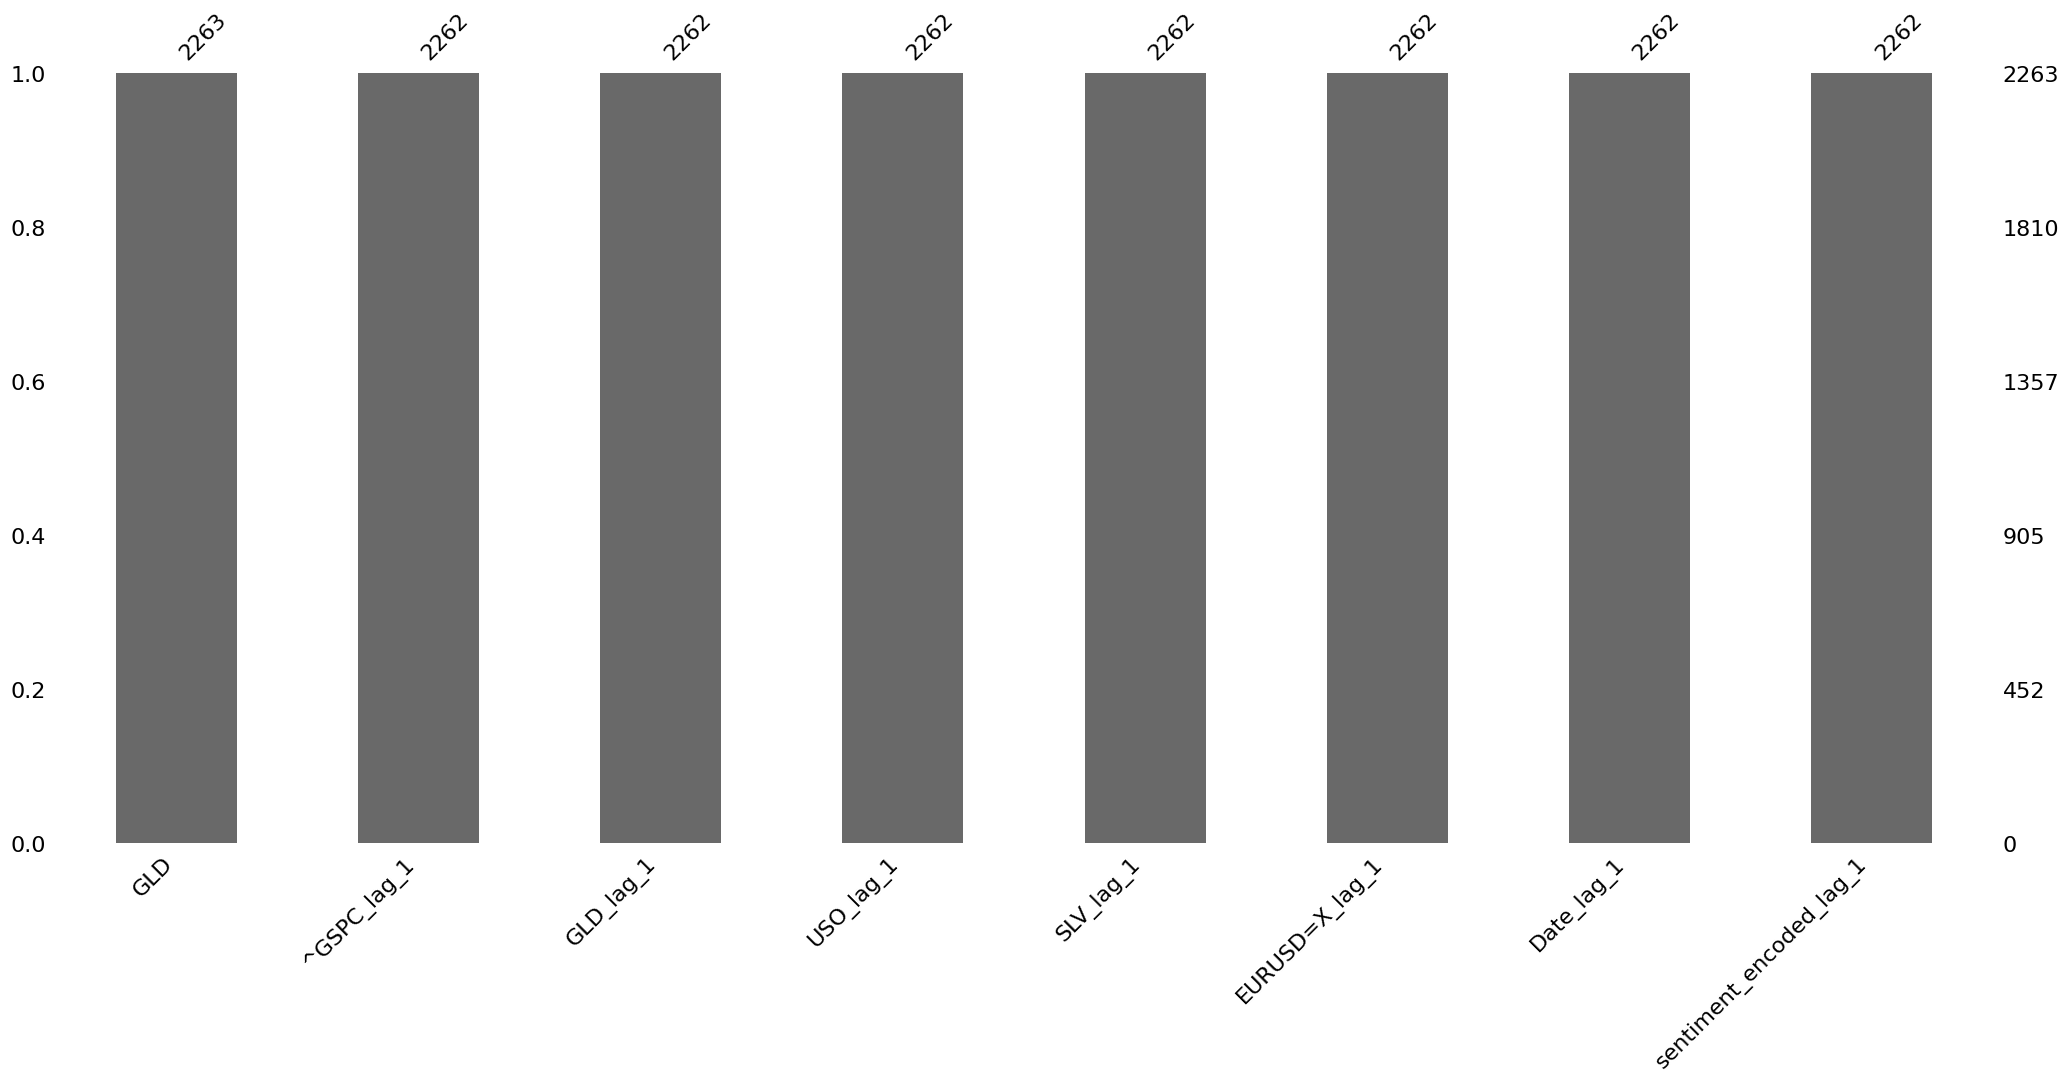

In [39]:
msno.bar(merged)
plt.show()

In [40]:
merged = merged.dropna()
merged.isnull().sum()

GLD                        0
^GSPC_lag_1                0
GLD_lag_1                  0
USO_lag_1                  0
SLV_lag_1                  0
EURUSD=X_lag_1             0
Date_lag_1                 0
sentiment_encoded_lag_1    0
dtype: int64

In [41]:
path = "../gdelt_gold_news_sentiment_clean.csv"
merged.to_csv(path, index=False)

In [42]:
path = "../gdelt_gold_news_sentiment_clean.csv"
df = pd.read_csv(path)
df.head()

,GLD,^GSPC_lag_1,GLD_lag_1,USO_lag_1,SLV_lag_1,EURUSD=X_lag_1,Date_lag_1,sentiment_encoded_lag_1
0,102.199997,2056.500000,102.269997,87.440002,13.29,1.096599,2015-12-28,2.0
1,101.419998,2078.360107,102.199997,90.080002,13.27,1.097526,2015-12-29,2.0
2,101.459999,2063.360107,101.419998,87.440002,13.21,1.092801,2015-12-30,2.0
3,102.889999,2043.939941,101.459999,88.000000,13.19,1.093398,2015-12-31,2.0
4,103.180000,2012.660034,102.889999,87.839996,13.19,1.085399,2016-01-04,2.0


In [54]:
X = df[['^GSPC_lag_1', 'GLD_lag_1', 'USO_lag_1', 'SLV_lag_1', 'EURUSD=X_lag_1', 'sentiment_encoded_lag_1']]
y = df['GLD']

# --- Split the data ---
n = len(df)
train_end = int(0.8 * n)
val_end = int(0.85 * n)  # next 5%

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

# --- Create XGBoost regressor ---
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Use callbacks for early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True,
)

# --- Predictions ---
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# --- Evaluation ---

def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)  # always returns MSE
    rmse = np.sqrt(mse)                       # take sqrt manually
    r2 = r2_score(y_true, y_pred)
    print(f"{label} RMSE: {rmse:.4f}, R2: {r2:.4f}")

evaluate(y_train, y_train_pred, 'Train')
evaluate(y_val, y_val_pred, 'Validation')
evaluate(y_test, y_test_pred, 'Test')

[0]	validation_0-rmse:37.94148
[1]	validation_0-rmse:36.18880
[2]	validation_0-rmse:34.51467
[3]	validation_0-rmse:32.95165
[4]	validation_0-rmse:31.44713
[5]	validation_0-rmse:30.24617
[6]	validation_0-rmse:28.86479
[7]	validation_0-rmse:27.53042
[8]	validation_0-rmse:26.28234
[9]	validation_0-rmse:25.29860
[10]	validation_0-rmse:24.16628
[11]	validation_0-rmse:23.29844
[12]	validation_0-rmse:22.50211
[13]	validation_0-rmse:21.76452
[14]	validation_0-rmse:20.79076
[15]	validation_0-rmse:20.15095
[16]	validation_0-rmse:19.25834
[17]	validation_0-rmse:18.42543
[18]	validation_0-rmse:17.92436
[19]	validation_0-rmse:17.16425
[20]	validation_0-rmse:16.55502
[21]	validation_0-rmse:16.01650
[22]	validation_0-rmse:15.50192
[23]	validation_0-rmse:15.08408
[24]	validation_0-rmse:14.46035
[25]	validation_0-rmse:13.86838
[26]	validation_0-rmse:13.29190
[27]	validation_0-rmse:12.74326


[28]	validation_0-rmse:12.21467
[29]	validation_0-rmse:11.74911
[30]	validation_0-rmse:11.38806
[31]	validation_0-rmse:11.05840
[32]	validation_0-rmse:10.62117
[33]	validation_0-rmse:10.21216
[34]	validation_0-rmse:9.82753
[35]	validation_0-rmse:9.48099
[36]	validation_0-rmse:9.25770
[37]	validation_0-rmse:8.91314
[38]	validation_0-rmse:8.58560
[39]	validation_0-rmse:8.39424
[40]	validation_0-rmse:8.20518
[41]	validation_0-rmse:7.99567
[42]	validation_0-rmse:7.81363
[43]	validation_0-rmse:7.55278
[44]	validation_0-rmse:7.40104
[45]	validation_0-rmse:7.23642
[46]	validation_0-rmse:7.01833
[47]	validation_0-rmse:6.80985
[48]	validation_0-rmse:6.58695
[49]	validation_0-rmse:6.41712
[50]	validation_0-rmse:6.22894
[51]	validation_0-rmse:6.06274
[52]	validation_0-rmse:5.94132
[53]	validation_0-rmse:5.77353
[54]	validation_0-rmse:5.68765
[55]	validation_0-rmse:5.52532
[56]	validation_0-rmse:5.38452
[57]	validation_0-rmse:5.26499
[58]	validation_0-rmse:5.12909
[59]	validation_0-rmse:5.01217
[6

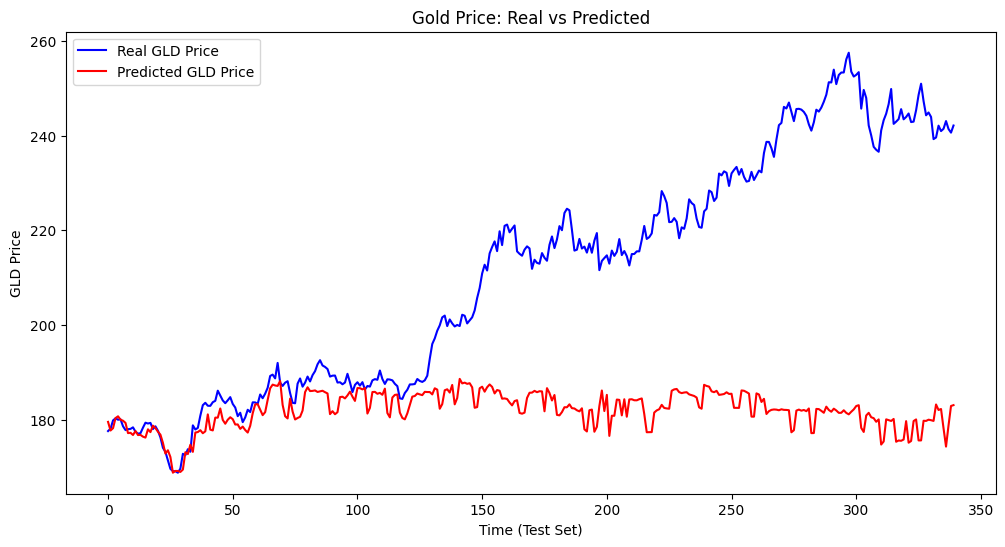

In [50]:
plt.figure(figsize=(12,6))

# Plot real prices
plt.plot(y_test.values, label='Real GLD Price', color='blue')

# Plot predicted prices
plt.plot(y_test_pred, label='Predicted GLD Price', color='red')

plt.title('Gold Price: Real vs Predicted')
plt.xlabel('Time (Test Set)')
plt.ylabel('GLD Price')
plt.legend()
plt.show()